Displaying Original Image...


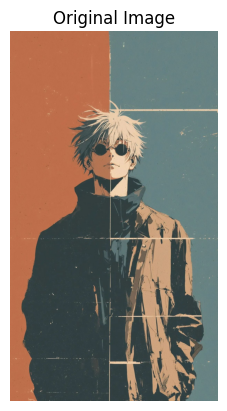

Image encrypted.
Image decrypted.
Displaying Decrypted Image...


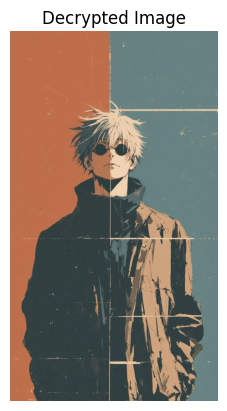

Decrypted image saved to decrypted_image.jpg


In [2]:
# Requires:
# pip install cryptography pillow matplotlib

from cryptography.hazmat.primitives.ciphers.aead import AESGCM
from cryptography.hazmat.primitives import hashes, serialization
from cryptography.hazmat.primitives.asymmetric import padding, rsa
import matplotlib.pyplot as plt
from PIL import Image
import os

# ------------------ KEY GENERATION (For testing) ------------------
def generate_keys():
    private_key = rsa.generate_private_key(
        public_exponent=65537,
        key_size=2048
    )
    public_key = private_key.public_key()

    priv_pem = private_key.private_bytes(
        encoding=serialization.Encoding.PEM,
        format=serialization.PrivateFormat.PKCS8,
        encryption_algorithm=serialization.NoEncryption()
    )

    pub_pem = public_key.public_bytes(
        encoding=serialization.Encoding.PEM,
        format=serialization.PublicFormat.SubjectPublicKeyInfo
    )

    return priv_pem, pub_pem

# ------------------ HYBRID ENCRYPTION ------------------
def encrypt_image_hybrid(image_bytes: bytes, recipient_pub_pem: bytes):
    pub = serialization.load_pem_public_key(recipient_pub_pem)

    K = os.urandom(32)  # AES-256 key
    aesgcm = AESGCM(K)
    iv = os.urandom(12)
    C = aesgcm.encrypt(iv, image_bytes, None)

    EncK = pub.encrypt(
        K,
        padding.OAEP(
            mgf=padding.MGF1(algorithm=hashes.SHA256()),
            algorithm=hashes.SHA256(),
            label=None,
        ),
    )

    digest = hashes.Hash(hashes.SHA256())
    digest.update(C)
    H = digest.finalize()

    return { "EncK": EncK, "iv": iv, "ciphertext": C, "hash": H }

# ------------------ HYBRID DECRYPTION ------------------
def decrypt_image_hybrid(package: dict, recipient_priv_pem: bytes):
    priv = serialization.load_pem_private_key(recipient_priv_pem, password=None)

    K = priv.decrypt(
        package["EncK"],
        padding.OAEP(
            mgf=padding.MGF1(algorithm=hashes.SHA256()),
            algorithm=hashes.SHA256(),
            label=None,
        ),
    )

    aesgcm = AESGCM(K)
    image_bytes = aesgcm.decrypt(package["iv"], package["ciphertext"], None)

    return image_bytes

# ------------------ IMAGE PROCESSING ------------------
def display_image(title, image_bytes):
    img = Image.open(BytesIO(image_bytes))
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

from io import BytesIO

# ------------------ MAIN WORKFLOW ------------------
def main():
    # Load an image from disk
    input_path = "gojo_saturo.jpg"
    output_path = "decrypted_image.jpg"

    with open(input_path, "rb") as f:
        image_bytes = f.read()

    # Display original
    print("Displaying Original Image...")
    display_image("Original Image", image_bytes)

    # Generate RSA keys
    priv_pem, pub_pem = generate_keys()

    # Encrypt
    package = encrypt_image_hybrid(image_bytes, pub_pem)
    print("Image encrypted.")

    # Decrypt
    decrypted_bytes = decrypt_image_hybrid(package, priv_pem)
    print("Image decrypted.")

    # Display decrypted
    print("Displaying Decrypted Image...")
    display_image("Decrypted Image", decrypted_bytes)

    # Save decrypted output
    with open(output_path, "wb") as f:
        f.write(decrypted_bytes)

    print(f"Decrypted image saved to {output_path}")

# ------------------ RUN ------------------
if __name__ == "__main__":
    main()
